<a href="https://colab.research.google.com/github/zahrapramesti649-cell/heart-attack-risk-prediction/blob/main/notebooks/05_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Objective

This stage aims to develop a machine learning model to predict heart attack risk based on patient characteristics. The model will be evaluated to assess its performance in supporting data-driven decision-making in healthcare.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
df = pd.read_csv("/content/heart_attack_dataset.csv", sep=";")
df.head()

,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,...,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


In [10]:
X = df.drop('heart_attack_risk', axis=1)
y = df['heart_attack_risk']

In [11]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [13]:
model = RandomForestClassifier(random_state=42)

In [14]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['patient_id', 'age', 'resting_bp', 'cholesterol', 'fasting_blood_sugar',
       'max_heart_rate', 'exercise_angina', 'oldpeak', 'num_major_vessels',
       'bmi', 'family_history', 'diabetes', 'stress_level'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'chest_pain_type', 'resting_ecg', 'st_slope', 'thalassemia',
       'smoking_status', 'alcohol_consumption', 'physical_activity'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [21]:
y_pred = clf.predict(X_test)

In [18]:
accuracy_score(y_test, y_pred)

0.7664285714285715

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       815
           1       0.76      0.65      0.70       585

    accuracy                           0.77      1400
   macro avg       0.76      0.75      0.75      1400
weighted avg       0.77      0.77      0.76      1400



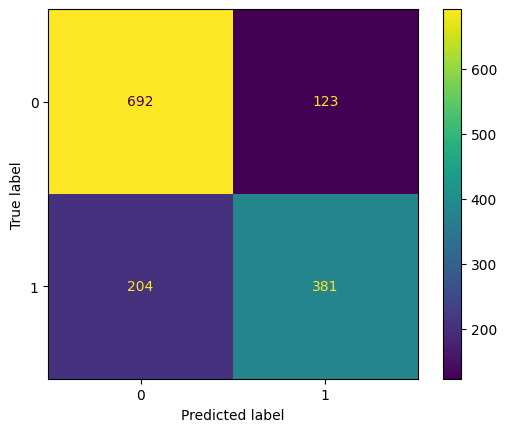

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

In [25]:
import pandas as pd

feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

importance = clf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
5,num__max_heart_rate,0.099643
1,num__age,0.097602
2,num__resting_bp,0.084411
7,num__oldpeak,0.083056
3,num__cholesterol,0.080305
9,num__bmi,0.071788
8,num__num_major_vessels,0.058985
0,num__patient_id,0.054327
12,num__stress_level,0.042214
11,num__diabetes,0.027592


### Model Evaluation

The Random Forest model successfully predicted the risk of heart attack with fairly good performance. An evaluation using a classification report demonstrated the model’s ability to distinguish between at-risk and non-at-risk patients.

These results indicate that the available data contains patterns that can be learned by machine learning models to support medical decision-making.